# 02. Action 도출
- LDA 토픽 모델링으로 각 Actor의 Action 세분화
- pyLDAvis 시각화로 토픽 해석

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
BASE_PATH = '/content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/CX 프로젝트/가전 구독/가전 구독'
os.chdir(BASE_PATH)
!pwd

In [22]:
!pip install -q new_value_analysis
!pip install -q pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 42.4 MB/s eta 0:00:00a 0:00:01


### 0. 클러스터 데이터 로딩

In [23]:
import pandas as pd

df = pd.read_pickle('./cluster_review.pkl')
print('전체 데이터 shape:', df.shape)
print('클러스터 분포:')
print(df['cluster'].value_counts().sort_index())

전체 데이터 shape: (313, 9)
클러스터 분포:
cluster
0    311
1      1
2      1
Name: count, dtype: int64


### 1. 분석할 Actor 선택
- TF-IDF 키워드 보고 유의미한 클러스터 번호 선택
- 클러스터마다 아래 셀부터 반복 실행

In [24]:
# ▶ 분석할 클러스터(Actor) 번호 지정
TARGET_ACTOR = 0

df_actor = df[df['cluster'] == TARGET_ACTOR].copy()
print(f'Actor {TARGET_ACTOR} 데이터 수: {len(df_actor)}건')

Actor 0 데이터 수: 311건


### 2. LDA 전처리 (단어사전 + BOW)

In [25]:
from gensim.corpora import Dictionary

all_documents = list(df_actor['tagged_review'])

# 단어사전 구축
word_dict = Dictionary(all_documents)
print('단어사전 크기:', len(word_dict))

# BOW 생성
corpus = [word_dict.doc2bow(doc) for doc in all_documents]
print('BOW 생성 완료')

단어사전 크기: 4248
BOW 생성 완료


### 3. 최적 토픽 수 선정 (Perplexity + Coherence)

  0%|          | 0/8 [00:00<?, ?it/s]

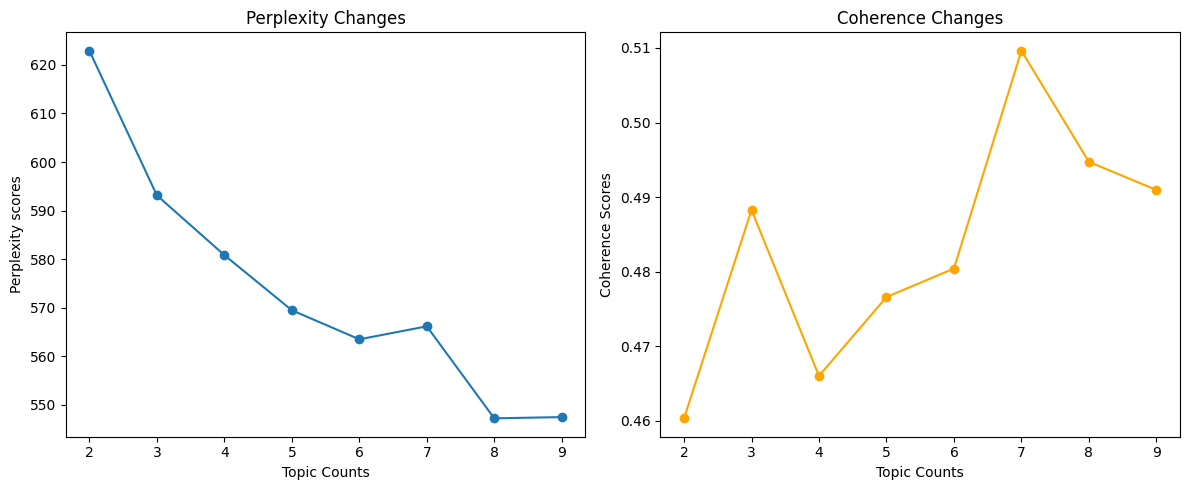

In [26]:
from new_value_analysis.action_finder import lda_perplexity_coherence_plot

lda_perplexity_coherence_plot(
    corpus=corpus,
    word_dict=word_dict,
    passes=10,
    iterations=20,
    topic_range=range(2, 10),
    random_state=2026,
    all_documents=all_documents,
    fixed_topn=10,
    figsize=(12, 5)
)
# ▶ coherence가 높은 구간 기준으로 토픽 수 결정

### 4. LDA 모델 학습

In [27]:
import gensim
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

# ▶ 위 그래프 보고 토픽 수 수정!
TOPIC_NUM = 7

ldamodel = gensim.models.ldamodel.LdaModel(
    corpus,
    id2word=word_dict,
    num_topics=TOPIC_NUM,
    passes=10,
    iterations=20,
    random_state=42
)

print('LDA 토픽별 주요 단어:')
for topic in ldamodel.print_topics(num_words=15):
    print(f'  Topic {topic[0]}: {topic[1]}')

LDA 토픽별 주요 단어:
  Topic 0: 0.016*"가전" + 0.015*"구독" + 0.013*"관리" + 0.010*"에어컨" + 0.010*"스타일러" + 0.010*"오브제" + 0.010*"사용" + 0.009*"제품" + 0.008*"케어" + 0.008*"건조기" + 0.008*"서비스" + 0.008*"컬렉션" + 0.008*"세탁" + 0.008*"세탁기" + 0.008*"기능"
  Topic 1: 0.052*"가전" + 0.038*"구독" + 0.017*"구매" + 0.013*"제품" + 0.012*"상담" + 0.012*"혜택" + 0.010*"베스트" + 0.010*"사용" + 0.010*"가능" + 0.010*"서비스" + 0.009*"냉장고" + 0.008*"기간" + 0.008*"세탁기" + 0.008*"비용" + 0.007*"필요"
  Topic 2: 0.026*"케어" + 0.026*"구독" + 0.020*"필터" + 0.020*"관리" + 0.019*"서비스" + 0.014*"제품" + 0.013*"사용" + 0.012*"구매" + 0.011*"가전" + 0.010*"에어컨" + 0.009*"교체" + 0.009*"청소" + 0.008*"청소기" + 0.008*"제습기" + 0.007*"먼지"
  Topic 3: 0.096*"렌탈" + 0.033*"가능" + 0.028*"구독" + 0.023*"비교" + 0.022*"제품" + 0.021*"답변" + 0.017*"신용" + 0.016*"인수" + 0.016*"가전제품" + 0.016*"비용" + 0.014*"선택" + 0.014*"방법" + 0.014*"가전" + 0.013*"설치" + 0.013*"카드"
  Topic 4: 0.034*"구독" + 0.033*"정수기" + 0.026*"렌탈" + 0.019*"혜택" + 0.016*"서비스" + 0.016*"가전" + 0.016*"최대" + 0.015*"사은품" + 0.014*"케어" + 0.014*"할인" + 0.013*"

### 5. pyLDAvis 시각화
- 왼쪽 원 크기 = 토픽 비중, 거리 = 토픽 간 유사도
- 오른쪽 = 해당 토픽의 핵심 단어
- lambda 0.5~0.6 권장

In [ ]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

prepared_data = gensimvis.prepare(ldamodel, corpus, word_dict)
pyLDAvis.display(prepared_data)
# ▶ 시각화 보고 LDA topic 번호 ↔ pyLDAvis 번호 매핑 확인

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### 6. Action 번호 할당 및 pyLDAvis 번호로 매핑

In [ ]:
from new_value_analysis.action_finder import assign_action_number

action_number_assignment = assign_action_number(ldamodel, corpus=corpus)
df_actor['action_cluster'] = action_number_assignment

print('Action 분포 (LDA 기준):')
print(df_actor['action_cluster'].value_counts().sort_index())

Action 분포 (LDA 기준):
action_cluster
0    41
1    53
2    19
3    59
4    41
5    41
6    57
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ▶ pyLDAvis 시각화 보고 아래 매핑 딕셔너리 수정!
# 예) LDA 0번 → pyLDAvis 1번 이면 {0: 1}
TOPIC_MAPPING = {
    0: 1,
    1: 2,
    2: 3,
    3: 4,
    4: ,
    5: ,
    6: 
}

df_actor['action_cluster'] = [TOPIC_MAPPING[i] for i in df_actor['action_cluster']]

print('Action 분포 (pyLDAvis 기준):')
print(df_actor['action_cluster'].value_counts().sort_index())

In [ ]:
# 저장
df_actor.to_pickle(f'./cluster_df_{TARGET_ACTOR}_action.pkl')
print(f'✅ cluster_df_{TARGET_ACTOR}_action.pkl 저장 완료')
print('\n▶ TARGET_ACTOR 번호 바꿔가며 모든 클러스터 반복 실행!')